# Lab 10

In [1]:
### MATPLOTLIB SETUP ###
import math
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
from scipy import signal
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
# Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Prelab

### Step 1: Compensator Requirements

Using what we've learned about designing loop shaping and the assignment parameters, we can determine the following requirements for our compensator

Given requirements:
- Output Voltage: 10V +/- 5%
- Zero steady-state error
- Closed-loop bandwidth equal to 1/8th switching frequency (6.25 kHz)
- Closed-loop damping ratio of 0.6

We can therefore choose:
- A pole at 0 (integrator) to remove DC error in the step response
- Crossover frequency - 4200kHz
    - We need a frequency well below the switching frequency and potential zeros to avoid susceptibility to noise. Additionally, we have a desired bandwith equal to 6.25 kHz, and from our lecture notes, the bandwidth is about 1.5 times gain crossover, and 4200 * 1.5 = 6300 - nearby our desired 6250
- Phase Margin - 60 degrees to avoid potential instability - also 60 degrees phase margin is correlated with a damping ratio of 0.6

With this crossover frequency in mind, we look at the 10V plant transfer function to find the magnitude and phase at our gain crossover

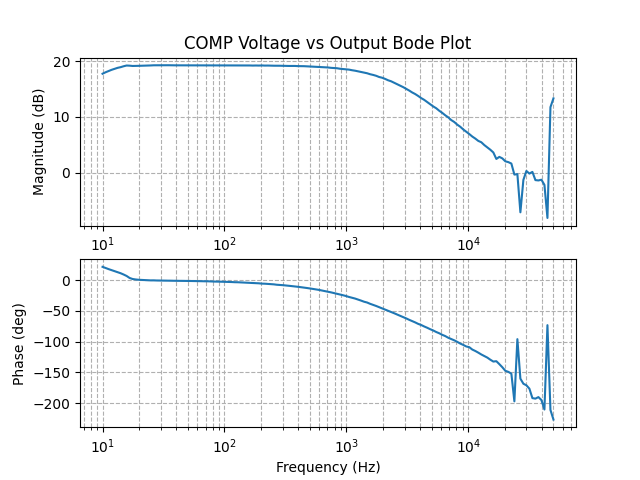

In [ ]:
v10 = pd.read_csv("../09-lab/data/10v.csv")

fig, (ax1, ax2) = plt.subplots(2,1)

p_freq = v10["Frequency (Hz)"]
p_mag = v10["Channel 2 Magnitude (dB)"]
p_phase = np.rad2deg(np.unwrap(np.deg2rad(v10['Channel 2 Phase (deg)'])))
ax1.plot(p_freq, p_mag)
ax2.plot(p_freq, p_phase)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (deg)")
ax1.set_title("COMP Voltage vs Output Bode Plot")
ax1.grid(True, which="both", ls="--")
ax2.grid(True, which="both", ls="--")


These values appear to be 13.25 dB gain and -74 degrees phase shift at 4200 Hz

With this in mind, we can calculate our $K_p$ factor to be -13.25dB to set the gain crossover to 4200 Hz

Now, we need to calculate our desired phase boost at the gain crossover frequency.

At the moment, our phase in the total system is -74 from the plant, plus -90 from the integrator in our compensator, for a total of -164. If we want our phase to be -120, we need a phase boost of 44 degrees. With this in mind, we can take our K factor to be

$$
\tan ( {\frac{\phi _{boost}}{2}+45 \degree} )
$$

With these values, we can now create our compensator transfer function

$$
G_c(s) = K_p \frac{\omega _i}{s} \sqrt{\frac{1+K^{-2}}{1+K^{2}}} \frac{s\frac{K}{\omega _c} + 1}{s \frac{1}{K\omega _c}+1}
$$

In [77]:
K = np.tan(np.deg2rad(44/2 + 45))
Kp = -13.25
Kp_linear = 0.22
wgc = 4200 * (2 * np.pi)
Gco = Kp_linear * wgc * np.sqrt((1+K**(-2))/(1+K**(2)))
print(f"Kp: {Kp}")
print(f"K: {K}")
print(f"wgc: {wgc}")
print(f"Gco: {Gco}")


Kp: -13.25
K: 2.355852365823753
wgc: 26389.37829015426
Gco: 2464.357829911772


### Component Selection

With these values in mind, we can begin component selection following the Type II Compensator Recipe.

First, we choose a value for Rf1 - looking at the component, I chose a value in the few kOhm ange - 3.9 kOhm.

Next, using the equation $Gc0 = \frac{1}{R_{f1} * C_{c1}}$, we calculate $C_{c1}$

With Cc1 in hand, we can now use $K = \sqrt{\frac{C_{c1}}{C_{c2}}}$ to find Cc2.

Knowing both capacitors, and that the center frequency of our lead element is the same as the gain crossover, we can apply $\omega _c = \frac{1}{R_{c1}\sqrt{C_{c1}C_{c2}}}$ to find Rc1

Lastly, we calculate the value for Rf2 that will reduce our output voltage to 2.5V with $R_{f2} = R_{f1} \frac{2.5}{V_o - 2.5}$

These calculations are performed in the code cell below.

In [ ]:
Rf1 = 4300
Cc1 = 1/(Rf1 * Gco)
Cc2 = Cc1/K**2
Rc1 = 1/(wgc * np.sqrt(Cc1*Cc2))
Rf2 = Rf1 * 2.5 / (10-2.5)

print(f"Rf1: {Rf1} Ohms")
print(f"Cc1: {Cc1} F")
print(f"Cc2: {Cc2} F")
print(f"Rc1: {Rc1} Ohms")
print(f"Rf2: {Rf2} Ohms")

Rf1: 4300 Ohms
Cc1: 9.436865730785925e-08 F
Cc2: 1.700323799903915e-08 F
Rc1: 946.0000000000003 Ohms
Rf2: 1433.3333333333333 Ohms


Looking at the componeny menu, I've selected these components

Rf1 - 4300 $\Omega$

Cc1 - 0.1 uF

Cc2 - 15nF

Rc1 - 1000 $\Omega$

Rf1 - 1500 $\Omega$

We can now from our parameters plot our bode plot of our compensator as well as the full open loop system.

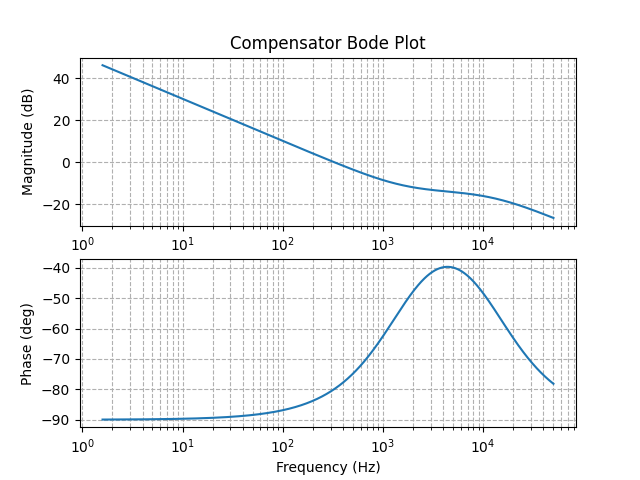

In [112]:
fig, (ax1, ax2) = plt.subplots(2,1)

Rf1 = 4300
Cc1 = 100e-9
Cc2 = 15e-9
Rc1 = 1000
Rf2 = 1500

ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (deg)")
ax1.set_title("Compensator Bode Plot")
ax1.grid(True, which="both", ls="--")
ax2.grid(True, which="both", ls="--")

n = [Rc1*Cc1, 1]
d = [Rf1 * (Cc1 + Cc2) * Rc1 * ((Cc1 * Cc2)/(Cc1 + Cc2)), Rf1 * (Cc1 + Cc2), 0]
transfer_function = signal.TransferFunction(n, d)

# Generate the Bode plot data
w = np.logspace(1,5.5,1000)
w, mag, phase = signal.bode(transfer_function, w)

ax1.semilogx(w/(2*np.pi), mag)
ax2.semilogx(w/(2*np.pi), phase)

This code cell takes our compensator plot and combines it with our theoretical plant transfer function calcaulted in lab 9 to get a combined open loop bode plot. 

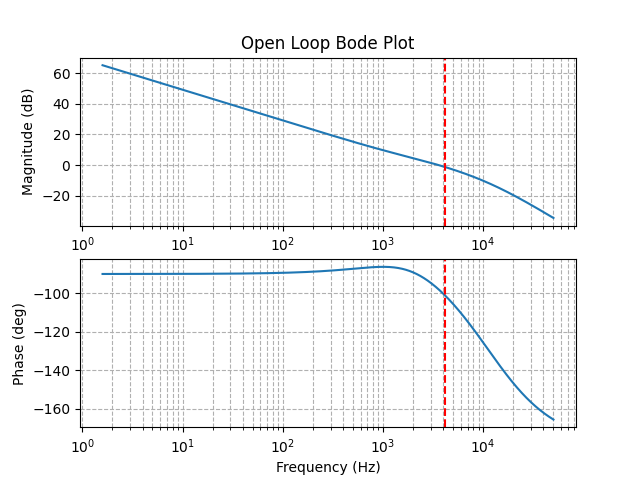

In [113]:
fig, (ax1, ax2) = plt.subplots(2,1)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (deg)")
ax1.set_title("Open Loop Bode Plot")
ax1.grid(True, which="both", ls="--")
ax2.grid(True, which="both", ls="--")

C = 28e-6 # with DC bias at 10V, output capacitance was measured at about 28uF in lab 5
L = 18.49e-6
alpha = L/2.8069306930693066e-05
Go = 8.89
n = [Go]
d = [R*C/2, 1]
plant_tf = signal.TransferFunction(n, d)

# Generate the Bode plot data
w = np.logspace(1,5.5,1000)
w, p_mag, p_phase = signal.bode(plant_tf, w)

ax1.semilogx(w/(2*np.pi), mag+p_mag)
ax2.semilogx(w/(2*np.pi), phase+p_phase)
ax1.axvline(x=4200, color='r', linestyle='--')
ax2.axvline(x=4200, color='r', linestyle='--')

From looking at this plot (with red lines on our desired gain crossover of 4200), we can see that the gain crossover is quite close to it, indicating that our bandwidth will be near the desired 6.25 kHz. Additionally, our phase margin is slightly over 60 degrees (about 80), meaning our closed-loop zeta will be near to  our desired 0.6. 

This is slightly further away than I would like, likely due to some error between the calculated component sizes and what is available on the menu, as well as this plot being made against a single pole approximation of our plant transfer function. However, even if the component selection causes a little bit of extra damping, that should hopefully still be ok for this lab.

On the voltage side, we can calculate our output voltage with the equation.

$$
V_o = V_{ref}  (1 + \frac{R_{f1}}{R_{f2}})
$$

In [114]:
V_out_calc = 2.5 * (1 + Rf1/Rf2) 
print(f"Vout = {V_out_calc} V")

Vout = 9.666666666666666 V
